Bygger en CSV fil med server objekt, att populera ett datacenter med.

In [6]:
import csv

In [7]:
csv_data = """Web-Server-01,192.168.1.10,16
Web-Server-02,192.168.1.11,16
Web-Server-03,192.168.1.12,8
App-Server-01,192.168.1.13,32
App-Server-02,192.168.1.14,32
App-Server-03,192.168.1.15,16
DB-Master-01,192.168.1.16,64
DB-Slave-01,192.168.1.17,32
DB-Slave-02,192.168.1.18,32
Backup-Server,192.168.1.19,8
Proxy-01,192.168.1.20,4
Proxy-02,192.168.1.21,4
Auth-Server,192.168.1.22,8
DNS-Server-01,192.168.1.23,4
DNS-Server-02,192.168.1.24,4
Monitoring-01,192.168.1.25,16
Storage-01,192.168.1.26,12
Storage-02,192.168.1.27,12
Dev-Server-01,192.168.1.28,8
Test-Server-01,192.168.1.29,4"""

with open("server.csv", "w", encoding="utf-8") as file:
    file.write(csv_data.strip())

print("En seed file för att populera datacenter med 20 enheter har skapats")

En seed file för att populera datacenter med 20 enheter har skapats


Ett första bygge av Klasser med arv

In [8]:
# Parent/Child klasser

class Hardware:
    def __init__(self, name: str, ip_address: str):
        self.name = name
        self.ip_address = ip_address
        self.status = "OK" 
        
class Server(Hardware):
    def __init__(self, name: str, ip_address: str, cpu_cores: int):
        super().__init__(name, ip_address)
        self.cpu_cores = cpu_cores

print("Parent Klass Hardware och Child  Klass Server har nu definierats i en första version")

Parent Klass Hardware och Child  Klass Server har nu definierats i en första version


Nu ska vi läsa in csv filen i internminnet i en så kallad lista (inventory[]), för att därefter populera upp datacenter

# inläsning av CSV fil

In [9]:
inventory = []

with open("server.csv", "r", encoding ="utf-8") as file:
    reader = csv.reader(file)
    for row in reader:
        server_object = Server(name=row[0], ip_address=row[1], cpu_cores=int(row[2]))
        inventory.append(server_object)
        
print(f"totalt antal inlästa server objekt är {len(inventory)}")
 

totalt antal inlästa server objekt är 20


Nu ska vi testa att läsa från inventory listan i minnet

In [10]:
print("läser vad som finns på rad två i listan (index startar från 0)")
print(f"namnet är:{inventory[1].name} IP är:{inventory[1].ip_address} antal cpu är {inventory[1].cpu_cores}")
print("\nläser innehållet i de tre första raderna i listan")
for srv in inventory[:3]:
    print(f"namnet är: {srv.name} IP är: {srv.ip_address} antal cpu är: {srv.cpu_cores}")        



läser vad som finns på rad två i listan (index startar från 0)
namnet är:Web-Server-02 IP är:192.168.1.11 antal cpu är 16

läser innehållet i de tre första raderna i listan
namnet är: Web-Server-01 IP är: 192.168.1.10 antal cpu är: 16
namnet är: Web-Server-02 IP är: 192.168.1.11 antal cpu är: 16
namnet är: Web-Server-03 IP är: 192.168.1.12 antal cpu är: 8


Nu testas förändring av värden i listan

In [11]:
print(f"vi ändrar antal cpu i Web-Server-3 från {inventory[2].cpu_cores} till {2*inventory[2].cpu_cores}")

# --- 4. FÖRÄNDRA ETT OBJEKT I LISTAN ---
# Vi hämtar databasservern (index 6 i listan) och simulera ett fel
ws_3 = inventory[2]
ws_3.cpu_cores = 2*inventory[2].cpu_cores 

print(f"{ws_3.name} har nu {ws_3.cpu_cores} cpu kärnor ")


for rader in inventory[:3]:
    rader.status = "Warning"
    print (rader.status, rader.name, rader.cpu_cores)   

for rader in inventory[:]:
    if rader.status == "Warning":
        rader.status = "CRITICAL"
        print(rader.status, rader.name, rader.cpu_cores)  
    
 

vi ändrar antal cpu i Web-Server-3 från 8 till 16
Web-Server-03 har nu 16 cpu kärnor 
Warning Web-Server-01 16
Warning Web-Server-02 16
Warning Web-Server-03 16
CRITICAL Web-Server-01 16
CRITICAL Web-Server-02 16
CRITICAL Web-Server-03 16


Nu ska vi ID tagga alla server objekt 
Målet är att varje server skall få en ID tagg (IT-01, IT-02 osv) 

In [12]:
id_counter = 1

class Hardware:
    def __init__(self, name: str, ip_address: str):
        global id_counter
        # varje NY instans får ett unikt ID när __init__ körs
        self.id_tag = f"ID-{id_counter}"
        id_counter += 1
        
        self.name = name
        self.ip_address = ip_address
        self.status = "OK"
        
        
class Server(Hardware):
    def __init__(self, name: str, ip_address: str, cpu_cores: int):
        # super() anropar Hardware.__init__ som sätter id_tag, name, ip_adress och status
        super().__init__(name, ip_address)
        self.cpu_cores = cpu_cores
        

inventory = []

with open("server.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    
    for row in reader:
        # När server() anropas körs __init__ så att id_tag skapas automatiskt
        server_object = Server(name=row[0], ip_address=row[1], cpu_cores=int(row[2]))
        inventory.append(server_object)
    

for srv in inventory:
    print(f"{srv.id_tag} {srv.name}")
    
print("Nu har alla servrar id taggats via en ny attribut och metod i Parent Class hardware")

ID-1 Web-Server-01
ID-2 Web-Server-02
ID-3 Web-Server-03
ID-4 App-Server-01
ID-5 App-Server-02
ID-6 App-Server-03
ID-7 DB-Master-01
ID-8 DB-Slave-01
ID-9 DB-Slave-02
ID-10 Backup-Server
ID-11 Proxy-01
ID-12 Proxy-02
ID-13 Auth-Server
ID-14 DNS-Server-01
ID-15 DNS-Server-02
ID-16 Monitoring-01
ID-17 Storage-01
ID-18 Storage-02
ID-19 Dev-Server-01
ID-20 Test-Server-01
Nu har alla servrar id taggats via en ny attribut och metod i Parent Class hardware


Nu ska vi göra samma sak men genom att arbeta med listan i minnet och 
utöka med en label som heter id_tag, och inte bara instansera om alla objekt 

In [13]:
inventory = []
with open("server.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    for row in reader:    
        server_object = Server(name=row[0], ip_address=row[1], cpu_cores=int(row[2]))
        inventory.append(server_object)

print("Testar att skriva ut rad 3 för att verifiera att en lista skapats i minnet")
print (inventory[2].name)


Testar att skriva ut rad 3 för att verifiera att en lista skapats i minnet
Web-Server-03


Nu ska vi lägga till en klassvariabel i listan med de 
instanserade servrarna som redan ligger i minnet
Det gör vi genom att sätta en klassvariabel DIREKT 
på Parent Class Hardware genom hardware.datacenter_site = "DC_STOCKHOLM_ZONE_1"
Nu finns denna egenskap, dvs label sitenamn för varje server, AUTOMATISKT tillagd i samtliga serverobjekt i minnet 

In [14]:
print("Vi sätter den nya klassvariabeln datacenter_site till DC_STOCKHOLM_ZONE_1")
Hardware.datacenter_site = "DC_STOCKHOLM_ZONE_1"

print("Testar att skriva ut rad 3 för att verifiera att klassvariabeln skapats i minnet")
print (inventory[2].datacenter_site)

Vi sätter den nya klassvariabeln datacenter_site till DC_STOCKHOLM_ZONE_1
Testar att skriva ut rad 3 för att verifiera att klassvariabeln skapats i minnet
DC_STOCKHOLM_ZONE_1


Nu ska vi lägga till id_tagg till listan med de 
instanserade servrarna som redan ligger i minnet
Detta genom en for loop som säkerhetstaggar 
BEFINTLIG population, alltså jag instasierar INTE en ny.
Vi stegar igenom listan i minnet och sätter en ny instansvariabel (.security_tag)

In [15]:
# 1. LOOPA IGENOM ALLA SERVRAR OCH SÄTT TAGGEN
for server in inventory:
    if server.cpu_cores >= 32:
        server.security_tag = "High_Risk"
    elif server.cpu_cores >= 16:
        server.security_tag = "Medium_Risk"
    else:
        server.security_tag = "Low_Risk"

# 2. SKRIV UT DE 8 FÖRSTA SERVRARNA
print(f"{'NAMN':<15} | {'CPU':<5} | {'SÄKERHETSTAGG'}")
print("-" * 40)

for srv in inventory[:8]:
    print(f"{srv.name:<15} | {srv.cpu_cores:<5} | {srv.security_tag}")

NAMN            | CPU   | SÄKERHETSTAGG
----------------------------------------
Web-Server-01   | 16    | Medium_Risk
Web-Server-02   | 16    | Medium_Risk
Web-Server-03   | 8     | Low_Risk
App-Server-01   | 32    | High_Risk
App-Server-02   | 32    | High_Risk
App-Server-03   | 16    | Medium_Risk
DB-Master-01    | 64    | High_Risk
DB-Slave-01     | 32    | High_Risk


I detta exempel baseras security_tag på hårdvarukapacitet (CPU), medan warning_tag baseras på en helt annan regel (t.ex. om servern har för lite RAM-minne för sin CPU-kraft):
BÅDA TAGGARNA NU INUTI Server class

In [16]:
class Hardware:

    def __init__(
        self, name: str, ip_address: str, power_watts: int, asset_tag: str = ""
    ):
        self.name = name
        self.ip_address = ip_address
        self.power_watts = power_watts
        self.asset_tag = asset_tag
        self.status = "OK"


class Server(Hardware):

    def __init__(
        self,
        name: str,
        ip_address: str,
        power_watts: int,
        cpu_cores: int,
        ram_gb: int,
        asset_tag: str = "",
    ):
        # 1. Anropa parent-klassen med super()
        super().__init__(name, ip_address, power_watts, asset_tag)

        # 2. Grundläggande specifikationer
        self.cpu_cores = cpu_cores
        self.ram_gb = ram_gb

        # 3. TAGG 1: Security Tag (Baserat på CPU-kärnor / Riskprofil)
        if self.cpu_cores >= 32:
            self.security_tag = "High_Risk"
        elif self.cpu_cores >= 16:
            self.security_tag = "Medium_Risk"
        else:
            self.security_tag = "Low_Risk"

        # 4. TAGG 2: Warning Tag (Baserat på resursbalans / Varningar)
        # Regel: Om vi har mycket CPU (>=16) men lite RAM (<32GB) varnar vi för flaskhals
        if self.cpu_cores >= 16 and self.ram_gb < 32:
            self.warning_tag = "RAM_BOTTLENECK_WARNING"
        elif self.power_watts > 600:
            self.warning_tag = "HIGH_POWER_WARNING"
        else:
            self.warning_tag = "NO_WARNING"


# =====================================================================
# TESTA ATT SKAPA OCH SKRIVA UT SERVRARNA
# =====================================================================

inventory = [
    Server(
        "Web-Server-01",
        "192.168.1.10",
        power_watts=400,
        cpu_cores=16,
        ram_gb=16,
        asset_tag="HW-1",
    ),  # RAM-flaskhals!
    Server(
        "App-Server-01",
        "192.168.1.20",
        power_watts=750,
        cpu_cores=32,
        ram_gb=128,
        asset_tag="HW-2",
    ),  # Hög strömförbrukning!
    Server(
        "Test-Server-01",
        "192.168.1.30",
        power_watts=200,
        cpu_cores=4,
        ram_gb=16,
        asset_tag="HW-3",
    ),  # Helt OK
]

print(
    f"{'NAMN':<15} | {'SECURITY TAG':<13} | {'WARNING TAG':<23} | {'POWER'}"
)
print("-" * 65)

for srv in inventory:
    print(
        f"{srv.name:<15} | {srv.security_tag:<13} | {srv.warning_tag:<23} | {srv.power_watts}W"
    )

NAMN            | SECURITY TAG  | WARNING TAG             | POWER
-----------------------------------------------------------------
Web-Server-01   | Medium_Risk   | RAM_BOTTLENECK_WARNING  | 400W
App-Server-01   | High_Risk     | HIGH_POWER_WARNING      | 750W
Test-Server-01  | Low_Risk      | NO_WARNING              | 200W


Problemet här är att vi behöver instansera om server objekten vid tillägg av taggar (labels/kolumner). Därför behöver vi frångå hårda taggar som kräver ominstansering och i stället titta på
dynamiska set med taggar på levande objekt. 


men...

Att kasta in fridrivande textsträngar i en set() eller ändra godtyckliga variabler under drift kallas i branschen för "Magic Strings" och "Unstructured State". Det är en känd källa till buggar eftersom stavfel (t.ex. "GOLD_SLA" vs "gold_sla") inte upptäcks av Python och det finns ingen validering.

För ett stabilt, professionellt och lättunderhållet DCIM-system finns det två betydligt bättre och renare arkitekturmönster.

Det Bästa Alternativet: Beräknade Egenskaper (@property)
Istället för att spara en sekundär tagg eller variabel i minnet och behöva "uppdatera" den manuellt när saker ändras, beräknar vi statusen dynamiskt när någon ber om den.

Varför detta är överlägset:
Single Source of Truth: Du har bara en sanningskälla (förhållandet mellan cpu_cores och ram_gb).

Noll synkroniseringsfel: Du kan aldrig glömma att uppdatera taggen – den räknas ut exakt i samma stund du frågar efter den.

Ingen minnesbelastning: Inga extra variabler eller listor sparas på objektet.


Kodexempel: Rent & Stabilt med @property

OBSERVERA EXTRA NOGA @property dekoratorn


In [17]:
class Hardware:

    def __init__(
        self, 
        name: str, 
        ip_address: str, 
        power_watts: int, 
        asset_tag: str = ""
    ):
        self.name = name
        self.ip_address = ip_address
        self.power_watts = power_watts
        self.asset_tag = asset_tag
        self.status = "OK"


class Server(Hardware):

    def __init__(
        self,
        name: str,
        ip_address: str,
        power_watts: int,
        cpu_cores: int,
        ram_gb: int,
        asset_tag: str = "",
    ):
        super().__init__(name, ip_address, power_watts, asset_tag)
        self.cpu_cores = cpu_cores
        self.ram_gb = ram_gb

    # --- BERÄKNADE EGENSKAPER (COMPUTED PROPERTIES) ---

    @property
    def security_level(self) -> str:
        """Räknar ut säkerhetsklass dynamiskt baserat på hårdvarans tillstånd."""
        if self.cpu_cores >= 32:
            return "HIGH_RISK"
        elif self.cpu_cores >= 16:
            return "MEDIUM_RISK"
        return "LOW_RISK"

    @property
    def has_bottleneck(self) -> bool:
        """Kollar om servern har för lite RAM i förhållande till sina CPU-kärnor."""
        return self.cpu_cores >= 16 and self.ram_gb < 32


# =====================================================================
# TESTA I DRIFT
# =====================================================================

# 1. Vi skapar 3 servrar i drift
inventory = [
    Server("Web-01", "192.168.1.10", 400, cpu_cores=16, ram_gb=16, asset_tag="HW-1"),
    Server("App-01", "192.168.1.20", 750, cpu_cores=32, ram_gb=128, asset_tag="HW-2"),
    Server("DB-01", "192.168.1.30", 200, cpu_cores=8, ram_gb=32, asset_tag="HW-3"),
]

# 2. Skriv ut rapporten
print(
    f"{'NAMN':<10} | {'CPU':<4} | {'RAM':<5} | {'RISKKLASS':<12} | {'FLASKHALS?'}"
)
print("-" * 55)

for srv in inventory:
    # Vi anropar .security_level och .has_bottleneck som om de vore vanliga variabler!
    print(
        f"{srv.name:<10} | {srv.cpu_cores:<4} | {srv.ram_gb:<5} | {srv.security_level:<12} | {srv.has_bottleneck}"
    )

NAMN       | CPU  | RAM   | RISKKLASS    | FLASKHALS?
-------------------------------------------------------
Web-01     | 16   | 16    | MEDIUM_RISK  | True
App-01     | 32   | 128   | HIGH_RISK    | False
DB-01      | 8    | 32    | LOW_RISK     | False


In [18]:
# Vi gör en hårdvaruuppgradering i minnet
srv = inventory[0]  # Web-01
srv.ram_gb = 64  # Nytt RAM-minne

# När vi läser av har flaskhalsen försvunnit 
# AUTOMATISKT utan att vi uppdaterade några taggar!
print(f"Web-01 Flaskhals efter uppgradering: {srv.has_bottleneck}") 
# Outputs: False

Web-01 Flaskhals efter uppgradering: False


"Att manuellt lägga till och ändra lösa tagg-variabler i efterhand skapar risk för osynkroniserad data och är svårt att felsöka. I mitt DCIM-system använder jag därför Computed Properties (@property).

Det gör att egenskaper som riskklass och prestandaflaskhalsar beräknas direkt utifrån objektets grunddata när de efterfrågas. Om en server får mer minne eller ändrar status i drift, speglas det direkt i beräkningen utan att vi behöver köra uppdateringsskript eller riskera att sekundära variabler blir inaktuella."

# Del 2. Sensorer och övervakning 

Steg 1: Objektinteraktion (Separation of Concerns)
I OOP är det en viktig princip att varje klass har sitt eget ansvarsområde:

En Server håller koll på sina specifikationer (CPU, RAM, IP-adress).

En TemperatureSensor håller koll på fysisk temperatur och mäter en specifik enhet.

För att sensorn ska kunna övervaka servern skickar vi med serverobjektet som en referens till sensorn när den skapas:

In [19]:
# Här skapar vi Sensor klassen

class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        # Vi sparar en referens till HÅRDVARUOBJEKTET direkt inuti sensorn!
        self.target_hardware = target_hardware
        self.current_temp = 22.0  # Starttemperatur i Celsius

    def read_temperature(self) -> float:
        """Returnerar den nuvarande temperaturen."""
        # self.current_temp = self.current_temp+1
        return self.current_temp
    
    def get_sensor_status(self):
        temp = self.read_temperature()
        return f"Sensor[{self.sensor_id}] på [{self.target_hardware.name}]: [{temp}] °C"

    def update_temperature(self, new_temp: float):
        """Uppdaterar temperaturen OCH ändrar status på servern om det blir för varmt."""
        self.current_temp = new_temp

        # Här läser vi av temperaturen och kollar tröskelvärdena:
        if self.current_temp >= 75.0:
            self.target_hardware.status = "CRITICAL"
        elif self.current_temp >= 50.0:
            self.target_hardware.status = "WARNING"
        else:
            self.target_hardware.status = "OK"



Här skapar vi servern som ska övervakas via sensorn
som vi också skapar här.

In [20]:
# 1. Skapa servern
my_server = Server(
    "Web-Server-01", "192.168.1.10", power_watts=400, cpu_cores=16, ram_gb=32
)

# 2. Skapa sensorn och peka ut servern som target!
sensor_1 = TemperatureSensor(
    sensor_id="TEMP-001", target_hardware=my_server
)

# 3. Sensorn kan nu komma åt serverns namn via sin referens:
print(
    f"Sensorn {sensor_1.sensor_id} övervakar just nu: {sensor_1.target_hardware.name}"
)

print(sensor_1.read_temperature())

sensor_1.read_temperature()
sensor_1.get_sensor_status()


Sensorn TEMP-001 övervakar just nu: Web-Server-01
22.0


'Sensor[TEMP-001] på [Web-Server-01]: [22.0] °C'

Nytt test, nu med ändring av temperatur genom metoden update_temperature

In [21]:
# Skapa server och sensor
server = Server("Web-01", "192.168.1.10", 400, 16, 32)
sensor = TemperatureSensor("TEMP-01", server)

print("Status före:", server.status)  # Borde vara OK

# Ändra temperaturen till 82 grader
sensor.update_temperature(82.0)

print("Ny temp via read_temperature():", sensor.read_temperature())
print("Status efter värmebölja:", server.status)  # Borde ha blivit CRITICAL!

Status före: OK
Ny temp via read_temperature(): 82.0
Status efter värmebölja: CRITICAL


Testar nu med en random snurra för olika temperatur och därmed olika reaktion

In [22]:
import random
import time
from datetime import datetime

# =====================================================================
# 1. KÖR EN SIMULERINGS-LOOP (5 MÄTNINGAR)
# =====================================================================

print("--- STARTAR AUTOMATISK TEMPERATURSIMULERING ---")

# Vi kör 5 slumpmässiga mätningar efter varandra
for i in range(1, 6):
    # Generera ett slumpmässigt värde mellan 25.0 °C och 90.0 °C (avrundat till 1 decimal)
    simulated_temp = round(random.uniform(25.0, 90.0), 1)

    # Skicka in det slumpade värdet till din uppdateringsmetod!
    sensor_1.update_temperature(simulated_temp)

    # Skriv ut vad som hände vid denna mätning
    print(
        f"Mätning {i}: Temp={simulated_temp:<4} °C | Server status: {my_server.status}"
    )

    # Lite paustid (0.5 sekunder) så att tidsstämplarna hinner skilja sig åt
    time.sleep(0.5)

print("\n--- SIMULERING KLAR ---")

--- STARTAR AUTOMATISK TEMPERATURSIMULERING ---
Mätning 1: Temp=29.4 °C | Server status: OK
Mätning 2: Temp=60.8 °C | Server status: WARNING
Mätning 3: Temp=53.4 °C | Server status: WARNING
Mätning 4: Temp=67.9 °C | Server status: WARNING
Mätning 5: Temp=71.5 °C | Server status: WARNING

--- SIMULERING KLAR ---


Steg 3 i Del 2: Enkel Fil-loggning
Det tredje och sista steget i Del 2 handlar om att spara larm till en textfil på disken.

När sensorn upptäcker en hög temperatur räcker det inte att ändra statusen i minnet – vi vill också att den skriver en rad i filen dcim_events.log.

För att lägga till text i en fil utan att radera det som redan står där använder vi läget "a" (append):

In [23]:
class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

    def read_temperature(self) -> float:
        return self.current_temp

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        # Om det blir för varmt: ändra status OCH skriv till fil
        if self.current_temp >= 75.0:
            self.target_hardware.status = "CRITICAL"

            # Enkel fil-skrivning
            with open("dcim_events.log", "a") as f:
                f.write(
                    f"LARM: {self.target_hardware.name} har kritisk temp: {self.current_temp} °C\n"
                )

        elif self.current_temp >= 50.0:
            self.target_hardware.status = "WARNING"

            with open("dcim_events.log", "a") as f:
                f.write(
                    f"VARNING: {self.target_hardware.name} har hög temp: {self.current_temp} °C\n"
                )

        else:
            self.target_hardware.status = "OK"

In [24]:
server = Server("Web-01", "192.168.1.10", 400, 16, 32)
sensor = TemperatureSensor("TEMP-01", server)

sensor.update_temperature(82.0)

with open("dcim_events.log", "r") as f:
    print(f.read())

LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 16:45:17 - ERROR - Web-01 är CRITICAL: 80.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:25:57 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:27:06 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 23:36:52 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:49:19 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10

In [25]:
import os

print("Filen sparades i denna mapp:")
print(os.getcwd())

# Kollar om filen faktiskt finns i minnet/disken just nu
print("Finns filen på disken?", os.path.exists("dcim_events.log"))

Filen sparades i denna mapp:
c:\Users\mansk\my_dcim
Finns filen på disken? True


Det fungerade sådär.
Därför kör vi nu påpå Pythons riktiga, inbyggda logging-modul!

Att manuellt öppna filer med open() fungerar, men i professionella Python-system använder man logging. Det ger dig automatiska tidsstämplar, loggnivåer (INFO, WARNING, ERROR) och hanterar filskrivningen i bakgrunden utan krångel.

💡 Hur logging fungerar (Grunden)
Istället för with open() konfigurerar vi loggern en gång högst upp i koden:

In [26]:
import logging

# 1. Konfigurera hur loggern ska bete sig
logging.basicConfig(
    filename="dcim_events.log",  # Filen som ska skapas
    level=logging.INFO,  # Lägsta nivå som ska sparas (INFO, WARNING, ERROR)
    format="%(asctime)s - %(levelname)s - %(message)s",  # Format på raden
    datefmt="%Y-%m-%d %H:%M:%S",  # Snygg tidsstämpel
)




Info kring logging

Nedan prövar vi logging modulen i vårat Temperatur Sensor scenario.

In [27]:
class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        if self.current_temp >= 75.0:
            self.target_hardware.status = "CRITICAL"
            # Skickar direkt till loggfilen som en ERROR
            logging.error(
                f"{self.target_hardware.name} är CRITICAL: {self.current_temp}°C"
            )

        elif self.current_temp >= 50.0:
            self.target_hardware.status = "WARNING"
            # Skickar direkt till loggfilen som en WARNING
            logging.warning(
                f"{self.target_hardware.name} har WARNING: {self.current_temp}°C"
            )

        else:
            self.target_hardware.status = "OK"
            
            
    

In [28]:
server2 = Server("Web-01", "192.168.1.10", 400, 16, 32)
sensor2 = TemperatureSensor("TEMP-01", server2)

sensor2.update_temperature(80.0)

In [29]:
with open("dcim_events.log", "r") as f:
    print(f.read())

LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 16:45:17 - ERROR - Web-01 är CRITICAL: 80.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:25:57 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:27:06 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 23:36:52 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:49:19 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10

 Ser du hur stor skillnaden är?
De första raderna var från din gamla with open()-lösning. Den sista raden:
2026-10-02 16:45:17 - ERROR - Web-01 är CRITICAL: 80.0°C
...visar exakt hur kraftfull logging-modulen är. Tidsstämpel, loggnivå (ERROR) och meddelande skapades helt automatiskt!


Övning 2: Logga när läget blir normalt (INFO)
I ett riktigt övervakningssystem vill vi inte bara logga när saker går sönder (ERROR / WARNING), utan även när en server återhämtar sig och blir grön/OK igen.

För normala händelser använder vi loggnivån logging.info().

In [30]:
class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        if self.current_temp >= 75.0:
            self.target_hardware.status = "CRITICAL"
            # Skickar direkt till loggfilen som en ERROR
            logging.error(
                f"{self.target_hardware.name} är CRITICAL: {self.current_temp}°C"
            )

        elif self.current_temp >= 50.0:
            self.target_hardware.status = "WARNING"
            # Skickar direkt till loggfilen som en WARNING
            logging.warning(
                f"{self.target_hardware.name} har WARNING: {self.current_temp}°C"
            )

        else:
            logging.info(
                f"{self.target_hardware.name} är i normal drift: {self.current_temp}°C"
            )

Höjer och sänker temperaturen för larm och återställning

In [31]:
server3 = Server("Web-01", "192.168.1.10", 400, 16, 32)
sensor3 = TemperatureSensor("TEMP-01", server3)

# 1. Höj temperaturen så det blir LARM
sensor3.update_temperature(85.0)
# 2. Sänk temperaturen så återställs LARM 
sensor3.update_temperature(35.0)

In [32]:
with open("dcim_events.log", "r") as f:
    print(f.read())

LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 16:45:17 - ERROR - Web-01 är CRITICAL: 80.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:25:57 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:27:06 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 23:36:52 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:49:19 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10

"Att använda Pythons logging-modul ger oss en strukturerad och konfigurerbar hantering av händelser. Vi får automatisk tidsstämpling, standardiserade formateringar och olika loggnivåer (INFO, WARNING, ERROR).

I en produktionsmiljö gör detta att vi enkelt kan filtrera loggar – till exempel söka efter enbart akuta ERROR-händelser – utan att behöva bygga egen strängformatering."

SAMMANFATTNING LARMNING OCH LOGGNING

✅ Objektinteraktion: Sensorn har en referens till servern och kan ändra dess status i minnet.

✅ Strukturerad Loggning: Alla varningar och återhämtningar skrivs automatiskt till fil med tidsstämpel via logging.

Modern IT-drift nyttjar AIOps (AI for IT Operations)
och Predictive Maintenance (förebyggande underhåll).
AI-modeller kräver standardiserade och strukturerade 
tröskellarm för att kunna träna på händelsekedjor 
till exempel: 
"Varje gång WARNING inträffar 3 gånger inom 10 minuter 
är det 85 % risk för en krasch."

Nedan följer tre korta, pedagogiska övningar inom AIOps

Övning 1: Datadriven modell (Tröskellista)
Varför den är viktig för AI/Arkitektur:

Olika typer av hårdvara tål olika mycket värme. En vanlig webbserver kanske varnar vid 50 °C, medan en AI/GPU-server kör mycket varmare och varnar först vid 75 °C. 

Testar nu att med en "AIOps" tröskellista skapa en enda klass 
vars temperatursensor kan anpassas till alla sorters hårdvara.

(Övning 1)
Skapa två olika servrar och två sensorer med olika känslighet:

Vanlig Server: Använder standardtrösklar enligt ASHRAE-standarden (American Society of Heating, Refrigerating and Air-Conditioning Engineers)

GPU-Server kör normalt varmare: Skapar därför en egen gpu_thresholds-lista 
där Varning utlöses först vid 65 °C!

In [33]:
import logging


class TemperatureSensor:

    def __init__(self, sensor_id: str, target_hardware, thresholds=None):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

        # TYDLIG OCH EXPLICIT LOGIK:
        # Om inga egna trösklar skickades med skapar vi standardlistan
        if thresholds is None:
            self.thresholds = [
                (18.0, 27.0, "OK"),  # Optimal rumstemperatur
                (27.0, 50.0, "WARNING"),  # Förhöjd värme
                (50.0, 150.0, "CRITICAL"),  # Akut överhettning
                (-50.0, 18.0, "TOO_COLD"),  # För kallt / Kondensrisk
            ]
        else:
            self.thresholds = thresholds

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        # Sök igenom regellistan och hitta vilket intervall temperaturen hamnar i
        for min_t, max_t, status in self.thresholds:
            if min_t <= self.current_temp < max_t:
                self.target_hardware.status = status

                # Logga med lämplig nivå i loggfilen
                if status == "CRITICAL":
                    logging.error(
                        f"[{self.target_hardware.name}] CRITICAL: {self.current_temp}°C"
                    )
                elif status in ("WARNING", "TOO_COLD"):
                    logging.warning(
                        f"[{self.target_hardware.name}] {status}: {self.current_temp}°C"
                    )
                else:
                    logging.info(
                        f"[{self.target_hardware.name}] OK: {self.current_temp}°C"
                    )

                break  # Avbryt loopen när rätt intervall hittats

In [34]:
# GPU-servrar tål högre värme i normal drift:
gpu_thresholds = [
    (18.0, 65.0, "OK"),  # Håller sig OK ända upp till 65 °C
    (65.0, 85.0, "WARNING"),  # Varnar först vid 65 °C
    (85.0, 150.0, "CRITICAL"),  # Kritisk först vid 85 °C
    (-50.0, 18.0, "TOO_COLD"),
]

# 1. Skapa servrar och sensorer
server_std = Server("Web-Server-01", "192.168.1.10", 400, 16, 32)
sensor_std = TemperatureSensor("TEMP-STD", server_std)  # Standardtrösklar

server_gpu = Server("GPU-AI-01", "192.168.1.20", 1200, 64, 256)
sensor_gpu = TemperatureSensor(
    "TEMP-GPU", server_gpu, thresholds=gpu_thresholds
)  # Högre värmetolerans

# 2. Testa BÅDA vid 60 °C:
sensor_std.update_temperature(60.0)
sensor_gpu.update_temperature(60.0)

print("--- Vid 60 °C ---")
print(
    "Standard Server status:", server_std.status
)  # Blir CRITICAL (för varmt för en standardserver)
print(
    "GPU Server status:     ", server_gpu.status
)  # Blir OK (helt normal arbetstemperatur för GPU)

--- Vid 60 °C ---
Standard Server status: CRITICAL
GPU Server status:      OK


Nu har vi gjort exmpel på datadriven arkitektur (tabelldriven logik)
Separation av ansvar: Klassen TemperatureSensor behöver bara veta hur den loopar igenom regler. Datan du skickar in (thresholds) bestämmer vilka regler som faktiskt gäller för just den hårdvaran

Open/Closed Principle (O:et i SOLID): Koden i sensorn är stängd för ändring (du behöver aldrig peta i klassen när ny hårdvara tillkommer), men öppen för utökning (du skapar bara en ny tröskellista).

Configuration over Code: Det är grunden för AIOps och enterprise-system. I ett riktigt produktionssystem läses dessa tröskellistor ofta in direkt från en JSON-fil, databas eller konfigurationsfil.

Introducerat i Python 3.10 är match / case Pythons motsvarighet till vad andra språk kallar switch-satser, fast mycket mer kraftfullt.

När vi ska utvärdera numeriska värden (som temperaturer) kombinerar vi case med ett villkor (s.k. guard): case temp if temp >= 75.0:.

💻 Kod: TemperatureSensor med match / case
Här är hur klassen ser ut när vi strukturerar bedömningen med mönstermatchning:

In [35]:
import logging


class TemperatureSensorMatchCase:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        # Matcha värdet på current_temp mot olika fall (cases)
        match self.current_temp:
            case temp if temp >= 75.0:
                self.target_hardware.status = "CRITICAL"
                logging.error(
                    f"[{self.target_hardware.name}] CRITICAL: {temp}°C"
                )

            case temp if temp >= 50.0:
                self.target_hardware.status = "WARNING"
                logging.warning(
                    f"[{self.target_hardware.name}] WARNING: {temp}°C"
                )

            case temp if temp < 18.0:
                self.target_hardware.status = "TOO_COLD"
                logging.warning(
                    f"[{self.target_hardware.name}] TOO_COLD: {temp}°C"
                )

            case _:  # "case _" fungerar som 'else' (fångar allt annat)
                self.target_hardware.status = "OK"
                logging.info(f"[{self.target_hardware.name}] OK: {temp}°C")

Exempel kopplat till match case klassen ovan

In [36]:
# 1. Skapa en server och den nya sensorn
server_mc = Server("Web-MC-01", "192.168.1.30", 400, 16, 32)
sensor_mc = TemperatureSensorMatchCase("TEMP-MC", server_mc)

# 2. Testa tre olika temperaturer
sensor_mc.update_temperature(22.0)
print("22 °C ger status:", server_mc.status)

sensor_mc.update_temperature(58.0)
print("58 °C ger status:", server_mc.status)

sensor_mc.update_temperature(81.0)
print("81 °C ger status:", server_mc.status)

22 °C ger status: OK
58 °C ger status: WARNING
81 °C ger status: CRITICAL


Det här är precis så man testar strömmande data (IoT-sensorer) i AIOps!

För att det ska se realistiskt ut låter vi inte bara temperaturen hoppa helt vilt, utan vi simulerar att den stiger eller sjunker gradvis (en så kallad random walk). Då ser vi hur statusen förändras i realtid över tid.

Vi använder två inbyggda Python-moduler:

random: För att skapa slumpmässiga temperaturförändringar.

time: För att lägga in time.sleep(1) så att loopen pausar 1 sekund mellan varje mätning.

💻 Simulering i Jupyter Notebook (10 live-mätningar)
Klistra in och kör koden nedan i en ny cell. Den kommer att uppdatera utskriften sekund för sekund:

In [37]:
import random
import time

# 1. Skapa server och sensor
sim_server = Server("Live-Web-01", "192.168.1.50", 400, 16, 32)
sim_sensor = TemperatureSensor("TEMP-SIM", sim_server)

# Starttemperatur
temp = 22.0

print("--- STARTAR LIVESIMULERING AV TEMPERATURSENSOR ---")
print("Mätningar pushas i realtid var 1:a sekund...\n")

# Kör 12 automatiska mätningar
for step in range(1, 13):
    # Simulera att temperaturen ändras lite slumpmässigt (-3°C till +8°C)
    temp_change = random.uniform(-3.0, 8.0)
    temp = round(temp + temp_change, 1)

    # Pusha det nya värdet till sensorn
    sim_sensor.update_temperature(temp)

    # Skriv ut live-status på skärmen
    print(
        f"Mätning {step:2d} | Temp: {temp:4.1f} °C | Server Status: {sim_server.status}"
    )

    # Vänta 1 sekund innan nästa temperaturvärde pushas
    time.sleep(1)

print("\n--- SIMULERING KLAR ---")

--- STARTAR LIVESIMULERING AV TEMPERATURSENSOR ---
Mätningar pushas i realtid var 1:a sekund...

Mätning  1 | Temp: 21.7 °C | Server Status: OK
Mätning  2 | Temp: 22.7 °C | Server Status: OK
Mätning  3 | Temp: 21.4 °C | Server Status: OK
Mätning  4 | Temp: 23.5 °C | Server Status: OK
Mätning  5 | Temp: 28.0 °C | Server Status: WARNING
Mätning  6 | Temp: 33.0 °C | Server Status: WARNING
Mätning  7 | Temp: 38.5 °C | Server Status: WARNING
Mätning  8 | Temp: 37.3 °C | Server Status: WARNING
Mätning  9 | Temp: 42.8 °C | Server Status: WARNING
Mätning 10 | Temp: 49.0 °C | Server Status: WARNING
Mätning 11 | Temp: 46.9 °C | Server Status: WARNING
Mätning 12 | Temp: 50.8 °C | Server Status: CRITICAL

--- SIMULERING KLAR ---


När loopen kört klart kollar vi loggen

for step in range(1, 13):

Skapar en loop som kör 12 gånger. range(1, 13) startar på 1 och stannar innan 13. Variabeln step håller koll på vilket mätningsnummer du är på (1, 2, 3 ... 12).

temp_change = random.uniform(-3.0, 8.0)

Slumpar fram ett decimaltal mellan -3.0 och +8.0. Det simulerar verkligheten: temperaturen kan sjunka lite grann (fläktarna kyler), men har en tendens att stiga oftare (hårdvaran jobbar).

temp = round(temp + temp_change, 1)

Adderar förändringen till den förra temperaturen och avrundar till 1 decimal via round(..., 1). Utan round() kan flyttal i Python ge fula avrundningsfel i minnet (som 24.300000000000004).

sim_sensor.update_temperature(temp)

Skickar det nya värdet till din sensor. Det är denna rad som sätter igång hela din arkitektur: sensorn utvärderar tröskellistan, ändrar sim_server.status och skriver larm till loggfilen om det behövs.

print(f"Mätning {step:2d} | Temp: {temp:4.1f} °C | Server Status: {sim_server.status}")

En formaterad sträng (f-string) med speciell kordinering för utskriften:

{step:2d}: Skriver ut heltalet step med en fast bredd på 2 tecken. Det gör att ensiffriga tal (1–9) och tvåsiffriga tal (10–12) hamnar i raka vertikala kolumner.

{temp:4.1f}: Formaterar decimaltalet temp så att det tar 4 teckens plats totalt och alltid visas med 1 decimal (.1f = 1 float decimal).

{sim_server.status}: Läger av serverns nya status i minnet direkt efter att sensorn kört.

In [38]:
with open("dcim_events.log", "r") as f:
    # Skriv ut de sista raderna som skapades
    print(f.read())

LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 16:45:17 - ERROR - Web-01 är CRITICAL: 80.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:25:57 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:27:06 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 23:36:52 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:49:19 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10

Nedan följer en uppdelning av funktionens tre delar:

random: Pythons inbyggda modul för slumpgenerering.

.uniform(a, b): Metoden som slumpar fram ett decimaltal (flyttal). Namnet uniform kommer från likformig sannolikhetsfördelning – det betyder att alla decimaltal inom intervallet har exakt lika stor chans att slumpas fram (t.ex. 2.4182..., -1.053... eller 7.991...).

-3.0, 8.0: Intervallets gränsvärden (lägsta och högsta möjliga värde).

🌡️ Varför detta är perfekt för en DCIM-simulering
Glidande värden (Kontinuerlig data): Fysiska sensorer mäter analoga värden med decimaler. Om du istället hade använt random.randint(-3, 8) hade du bara fått hela heltal (-3, 0, 5), vilket ger väldigt hackig och orealistisk data.

Inbyggd värmetrend: Genom att välja spannet -3.0 till +8.0 görs simuleringen avsiktligt osymmetrisk. Eftersom maxtaket (+8.0) är större än lägsta värdet (-3.0) kommer slumpen över tid att driva temperaturen uppåt. Det simulerar att servern jobbar hårt och bygger upp värme snabbare än fläktarna hinner kyla ner.

Mönster 3: Enum för Statusar!

I professionella system vill man till varje pris undvika "Magic Strings" – det vill säga att skriva fristående strängar som "CRITICAL", "WARNING" eller "OK" direkt i koden.

🛑 Problemet med Magic Strings
Om du råkar stava fel någonstans i koden (t.ex. "CRITIKAL" eller "ok" med gemener):

Python ger inget felmeddelande – det är ju bara en vanlig sträng!

AI-modeller och övervakningssystem som söker efter "CRITICAL" kommer missa händelsen helt.

Ingen automatisk kodkomplettering (Autocomplete) i Jupyter Notebook eller VS Code.

Lösningen: enum.Enum (Uppräknade typer)
Med Pythons inbyggda Enum-modul definierar du alla tillåtna statusar på ett och samma ställe. Då blir statusen en fast typ i ditt system.

Steg 1: Skapa Enum-klassen och uppdatera sensorn

In [39]:
from enum import Enum
import logging


# 1. Definiera alla giltiga statusar som en Enum
class ServerStatus(Enum):
    OK = "OK"
    WARNING = "WARNING"
    CRITICAL = "CRITICAL"
    TOO_COLD = "TOO_COLD"


# 2. Sensorklass som använder Enum istället för lösa strängar
class TemperatureSensorEnum:

    def __init__(self, sensor_id: str, target_hardware, thresholds=None):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

        # Tröskelregler med Enum-objekt istället för strängar
        if thresholds is None:
            self.thresholds = [
                (18.0, 27.0, ServerStatus.OK),
                (27.0, 50.0, ServerStatus.WARNING),
                (50.0, 150.0, ServerStatus.CRITICAL),
                (-50.0, 18.0, ServerStatus.TOO_COLD),
            ] # (min-t, max_t, status_enum)
        else:
            self.thresholds = thresholds

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        for min_t, max_t, status_enum in self.thresholds:
            if min_t <= self.current_temp < max_t:
                # Tilldela strängvärdet (.value) till servern
                self.target_hardware.status = status_enum.value

                # Jämför direkt mot Enum-typen (Säkert & stavfelsfritt!)
                if status_enum == ServerStatus.CRITICAL:
                    logging.error(
                        f"[{self.target_hardware.name}] {status_enum.value}: {self.current_temp}°C"
                    )
                elif status_enum in (
                    ServerStatus.WARNING,
                    ServerStatus.TOO_COLD,
                ): # ovan ersätter status_enum == ServerStatus.WARNING or status_enum == ServerStatus.TOO_COLD
                    # ett komma "," sist i en lista eller tuple kallas trailing comma. för tredje status enkelt.
                    logging.warning(
                        f"[{self.target_hardware.name}] {status_enum.value}: {self.current_temp}°C"
                    )
                else:
                    logging.info(
                        f"[{self.target_hardware.name}] {status_enum.value}: {self.current_temp}°C"
                    )

                break

Nu verifierar vi ENUM funktionaliteten

In [40]:
# Skapa server och Enum-sensor
server_enum = Server("Web-Enum-01", "192.168.1.60", 400, 16, 32)
sensor_enum = TemperatureSensorEnum("TEMP-ENUM", server_enum)

# Test 1: Normal temperatur
sensor_enum.update_temperature(23.0)
print("Status vid 23 °C:", server_enum.status)

# Test 2: Kritisk temperatur
sensor_enum.update_temperature(82.0)
print("Status vid 82 °C:", server_enum.status)

# Jämför direkt i din kod med Enum
if server_enum.status == ServerStatus.CRITICAL.value:
    print("AI-Agent alert: Åtgärd krävs omedelbart för", server_enum.name)

Status vid 23 °C: OK
Status vid 82 °C: CRITICAL
AI-Agent alert: Åtgärd krävs omedelbart för Web-Enum-01


Varför detta är guld värt för AIOps
När du senare ska bygga AI-modeller som analyserar loggar och tillstånd:
Du har en strikt datamodell (schema) – AI:n behöver aldrig gissa vad statusen betyder.

Du kan inte råka skicka ogiltig data till din databas eller AI-pipeline.

Vi har nu provat alla tre mönstren:

Datadriven modell (Flexibla tröskellistor per hårdvara)

match / case (Deklarativ mönstermatchning med guards)

Enum (Typsäkra statuskonstanter)


I professionell arkitektur kombineras ofta alla tre: Enum sätter den typsäkra datamodellen, Datadrivna tabeller gör trösklarna konfigurerbara, och match / case styr vad som ska hända vid varje enskilt tillstånd.

# Del 3: Felhantering (try/except) i DCIM

Del 3: Felhantering (try / except) i DCIM
I en verklig IoT- och datacenter miljö strömmar data in från tusentals fysiska sensorer. Förr eller senare kommer en sensor att skicka korrupt data – till exempel en sträng som "35.5C", ett tomrum None, ett nätverksfel eller ett helt orealistiskt värde som 9999.0 °C.

Om koden inte har felhantering kraschar hela övervakningssystemet direkt vid första dåliga mätvärdet.

Målet med felhantering i ett övervakningssystem
Robusthet: Systemet får aldrig krascha på grund av ett enskilt trasigt mätvärde.

Spårbarhet: Felet ska fångas upp, loggas som ett ERROR i dcim_events.log, och servern sätts till status "UNKNOWN" eller "SENSOR_FAULT".

Driftfortsättning: Sensorn ska fortsätta lyssna på nästa mätning som om ingenting hänt.

Steg 1: TemperatureSensor med try / except
Lägg märke till hur vi hanterar både datatypfel (TypeError, ValueError) och rimlighetsfelek (som fysikaliskt omöjliga temperaturer):

In [41]:
import logging
from enum import Enum


class ServerStatus(Enum):
    OK = "OK"
    WARNING = "WARNING"
    CRITICAL = "CRITICAL"
    TOO_COLD = "TOO_COLD"
    SENSOR_FAULT = "SENSOR_FAULT"  # Ny status vid sensorfel!
    # Observera tillägget av ny status kallad SENSOR_FAULT

class TemperatureSensorRobust:

    def __init__(self, sensor_id: str, target_hardware):
        self.sensor_id = sensor_id
        self.target_hardware = target_hardware
        self.current_temp = 22.0

        self.thresholds = [
            (18.0, 27.0, ServerStatus.OK),
            (27.0, 50.0, ServerStatus.WARNING),
            (50.0, 150.0, ServerStatus.CRITICAL),
            (-50.0, 18.0, ServerStatus.TOO_COLD),
        ]

    def update_temperature(self, raw_temp):
        """Tar emot raw_temp som kan vara vad som helst (float, int, str, None)."""
        try:
            # 1. Försök konvertera inkommande data till ett float-tal
            temp = float(raw_temp)

            # 2. Rimlighetskontroll (Validering av orimliga värden)
            if temp < -50.0 or temp > 150.0:
                raise ValueError(
                    f"Orimligt temperaturvärde från sensor: {temp}°C"
                )

            # Om konvertering och validering lyckades, spara värdet
            self.current_temp = temp

            # 3. Utvärdera trösklar
            for min_t, max_t, status_enum in self.thresholds:
                if min_t <= self.current_temp < max_t:
                    self.target_hardware.status = status_enum.value
                    logging.info(
                        f"[{self.target_hardware.name}] Status update: {status_enum.value} ({self.current_temp}°C)"
                    )
                    break

        except (ValueError, TypeError) as e:
            # Fånga upp om konverteringen misslyckades eller om värdet var orimligt
            self.target_hardware.status = ServerStatus.SENSOR_FAULT.value
            logging.error(
                f"[{self.target_hardware.name}] SENSOR ERROR on {self.sensor_id}: {e} (Mottaget: {raw_temp})"
            )


BREAK??!!
Varför är break avgörande här?
Undviker onödigt arbete (Prestanda):
Om din temperatur är 22 °C och den första regeln i listan är (18.0, 27.0, ServerStatus.OK), hittar koden en träff direkt på index 0. Utan break skulle Python i onödan fortsätta att kontrollera regeln för WARNING, CRITICAL och TOO_COLD, trots att vi redan vet svaret.

Förhindrar att statusen skrivs över:
Om du i framtiden har regler som överlappar varandra, eller om du ändrar ordningen i listan, garanterar break att det är den första giltiga regeln som vinner. Utan break körs loopen till sista elementet, vilket gör att den sista regeln som råkar vara sann är den som sätter den slutgiltiga statusen.

Sätter stopp för dubbla loggrader:
Eftersom logging.info() ligger inuti if-blocket ser break till att händelsen bara loggas en enda gång per temperaturuppdatering.

Vad skulle hända utan break?Jämför vad som händer i minnet när self.current_temp = 22.0:
Med break:Kollar regel 1 (18.0 <= 22.0 < 27.0) Träff! Sätter status till OK, loggar, och avbryter. (Totalt 1 jämförelse).
Utan break:Kollar regel 1  Träff! Sätter OK, loggar.Kollar regel 2 (27.0 <= 22.0 < 50.0) Falskt.Kollar regel 3 (50.0 <= 22.0 < 150.0) Falskt.Kollar regel 4 (-50.0 <= 22.0 < 18.0) Falskt.(Totalt 4 jämförelser – 3 av dem helt i onödan).

variabeln "e", eller "err" eler "exc"
💡 Varför kallas den oftast just e?
e (eller err / exc) är standardkonventionen i Python. Det håller koden kort och koncist samtidigt som det är uppenbart för alla Python-utvecklare att variabeln representerar det fångade undantaget.

I kodraden except (ValueError, TypeError) as e: är e variabelnamnet för det fångade felobjektet (kort för exception eller error).

När ett fel uppstår inuti try-blocket skapar Python ett objekt som innehåller information om exakt vad som gick snett. Med nyckelordet as e fångar du upp detta objekt och sparar det i variabeln e.

Vad innehåller variabeln e i praktiken?
Beroende på vilken typ av fel som inträffar får e två helt olika typer av innehåll:

1. Pythons egna systemfelmeddelanden
Om konverteringen float("KORRUPT_DATA") misslyckas, skapar Python ett standardfel.

e innehåller då texten:
could not convert string to float: 'KORRUPT_DATA'

2. DINA egna skräddarsydda felmeddelanden
När du manuellt kastade ett fel för orimliga temperaturer med raise ValueError(f"Orimligt temperaturvärde: {temp}°C"):

e innehåller då exakt din text:
Orimligt temperaturvärde från sensor: 999.0°C


Hur e används i loggningen
När du sätter in e i din f-sträng inuti loggfunktionen:

Python
logging.error(
    f"[{self.target_hardware.name}] SENSOR ERROR on {self.sensor_id}: {e} (Mottaget: {raw_temp})"
)
Omvandlar Python automatiskt objektet e till en textsträng (via dess inbyggda __str__-metod).

Istället för att du i loggen bara skriver "Det blev fel", gör e att det i dcim_events.log står exakt varför det sket sig:

ERROR: [Web-Robust-01] SENSOR ERROR on TEMP-ROBUST: could not convert string to float: 'KORRUPT_DATA' (Mottaget: KORRUPT_DATA)

Det beror på hur Pythons tolksystem och funktioner fungerar under huven. e är inte bara ett ord, utan ett komplett objekt som fylls med diagnostisk information i samma millisekund som felet uppstår.

1. Hur Python skapar felmeddelandet (Under huven)
När du anropar den inbyggda funktionen float("KORRUPT_DATA"), körs Pythons C-kod i bakgrunden:

float() analyserar tecknen i strängen "KORRUPT_DATA".

Den upptäcker att tecknen inte är giltiga siffror eller decimaltecken.

Istället för att krascha programmet skapar float() ett nytt ValueError-objekt.

float() skickar med en detaljerad textsträng in i objektets konstruktor:
ValueError("could not convert string to float: 'KORRUPT_DATA'")

2. Hur e blir till ren text i loggen
När du fångar felet med except (ValueError, TypeError) as e: binder du detta skapade objekt till variabeln e.

När du sedan stoppar in e i din f-sträng:

Python
logging.error(f"... {e} ...")
anropar Python automatiskt metoden str(e) (eller e.__str__()). ValueError-klassen har en inbyggd instruktion för hur den ska omvandla sig själv till text: den returnerar helt enkelt det felmeddelande som paketerades inuti objektet när felet uppstod.

De två källorna till texten i e
Det finns alltså två sätt som texten i e skapas på i din kod:
KällaExempel i koden
Vad e innehåller
Pythons inbyggda funktioner
float("KORRUPT_DATA")
Pythons utvecklare har skrivit exakta felmeddelanden i C-koden för float().

Dina egna valideringarraise ValueError("Orimligt temperaturvärde...")
Din egen text som du skickade med in i ValueError(...) när du "kastade" felet med raise.
Genom att använda {e} i loggen slipper du gissa vad som gick snett – du får automatiskt antingen Pythons exakta felbeskrivning eller din egen skräddarsydda förklaring!



Vi inspekterar detta direkt i Python:

In [42]:
try:
    float("KORRUPT_DATA")
except ValueError as e:
    print("Typ av objekt:", type(e))  # <class 'ValueError'>
    print("Innehållet i e: ", str(e))  # could not convert string to float: 'KORRUPT_DATA'
    print(
        "Rådata i e.args: ", e.args
    )  # ("could not convert string to float: 'KORRUPT_DATA'",)

Typ av objekt: <class 'ValueError'>
Innehållet i e:  could not convert string to float: 'KORRUPT_DATA'
Rådata i e.args:  ("could not convert string to float: 'KORRUPT_DATA'",)


Nu ska vi testa om fel kan fångas:

In [43]:
# Skapa server och robust sensor
server_robust = Server("Web-Robust-01", "192.168.1.70", 400, 16, 32)
sensor_robust = TemperatureSensorRobust("TEMP-ROBUST", server_robust)

# En lista med BÅDE giltiga och korrupta indata från sensorer
test_payloads = [
    24.5,  # Giltigt float
    "32.0",  # Sträng som GÅR att konvertera till float
    "KORRUPT_DATA",  # Textsträng som kraschar om man inte har try/except!
    None,  # Tomt värde (Nätverksbortfall)
    999.0,  # Fysiskt omöjligt temperaturvärde
    21.0,  # Giltigt värde igen (Visar att sensorn återhämtar sig!)
]

print("--- STARTAR STRESTEST AV SENSOR-FELHANTERING ---\n")

for i, raw_val in enumerate(test_payloads, 1):
    sensor_robust.update_temperature(raw_val)
    print(
        f"Test {i} | Inkommande data: {str(raw_val):<15} | Server Status: {server_robust.status}"
    )

print("\n--- TEST KLART! KONTROLLERA ATT KODEN INTE KRASCHADE ---")

--- STARTAR STRESTEST AV SENSOR-FELHANTERING ---

Test 1 | Inkommande data: 24.5            | Server Status: OK
Test 2 | Inkommande data: 32.0            | Server Status: WARNING
Test 3 | Inkommande data: KORRUPT_DATA    | Server Status: SENSOR_FAULT
Test 4 | Inkommande data: None            | Server Status: SENSOR_FAULT
Test 5 | Inkommande data: 999.0           | Server Status: SENSOR_FAULT
Test 6 | Inkommande data: 21.0            | Server Status: OK

--- TEST KLART! KONTROLLERA ATT KODEN INTE KRASCHADE ---


Här är en genomgång av STRESSTEST LOOPEN rad för rad:

1. for i, raw_val in enumerate(test_payloads, 1):
Den här raden kör två saker samtidigt:

test_payloads: Listan med dina testvärden (t.ex. 24.5, "KORRUPT_DATA", None).

enumerate(..., 1): Funktionen enumerate() parar ihop varje element i listan med ett ordningsnummer. Siffran 1 i slutet talar om att räknaren ska starta på 1 (istället för Pythons standard som är 0).

i, raw_val: Så kallad tuple unpacking. I varje varv tilldelas:

i = Testnumret (1, 2, 3...).

raw_val = Det faktiska mätvärdet från listan (24.5, "32.0", "KORRUPT_DATA" osv.).

2. sensor_robust.update_temperature(raw_val)
Här skickas det otestade mätvärdet in i din sensorklass. Det är denna rad som sätter igång din felhantering (try/except):

Försöker omvandla raw_val till ett float-tal.

Om det misslyckas fångas felet, loggas i dcim_events.log, och serverns status ändras till "SENSOR_FAULT".

Om det lyckas utvärderas tröskelvärdena och servern får sin rätta status (t.ex. "OK").

3. print(f"Test {i} | Inkommande data: {str(raw_val):<15} | Server Status: {server_robust.status}")
Skriver ut resultatet på skärmen som en snyggt formaterad tabellrad:

Test {i}: Skriver ut vilket test i ordningen det är (t.ex. "Test 1").

str(raw_val): Omvandlar värdet till textsträng så att även None eller siffror kan hanteras av textformateraren utan fel.

:<15 (Snygg tabelljustering):

< betyder vänsterjustera texten.

15 reserverar en fast bredd på 15 tecken.

Detta gör att oavsett om texten är kort ("24.5") eller lång ("KORRUPT_DATA"), så fyller Python ut med mellanslag upp till 15 tecken. Resultatet blir att nästa kolumn (| Server Status: ...) hamnar på exakt samma vertikala linje på varje rad!

{server_robust.status}: Hämtar serverns nyss uppdaterade status direkt ur minnet.

Hur utskriften ser ut tack vare formateringen

Test 1 | Inkommande data: 24.5            | Server Status: OK
Test 2 | Inkommande data: 32.0            | Server Status: WARNING
Test 3 | Inkommande data: KORRUPT_DATA    | Server Status: SENSOR_FAULT

Nu granskar vi innehållet i loggfilen

In [44]:
# Läs och skriv ut hela innehållet i loggfilen
with open("dcim_events.log", "r") as log_file:
    print("=== INNEHÅLL I DCIM_EVENTS.LOG ===")
    print(log_file.read())

=== INNEHÅLL I DCIM_EVENTS.LOG ===
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 16:45:17 - ERROR - Web-01 är CRITICAL: 80.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:25:57 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:25:57 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 17:27:06 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 17:27:06 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 80.0°C
2026-10-02 23:36:52 - ERROR - Web-01 är CRITICAL: 85.0°C
2026-10-02 23:36:52 - INFO - Web-01 är i normal drift: 35.0°C
LARM: Web-01 har kritisk temp: 82.0 °C
2026-10-02 23:49:19 - ERROR -

Analys av loggen
Giltig textsträng ("32.0"): Konverterades utan problem av float() till ett numeriskt värde (32.0) och uppdaterade statusen till WARNING.
Standard-Exceptions ("KORRUPT_DATA" och None): Fångades upp av TypeError/ValueError i except-blocket och sparade Pythons egna detaljerade felbeskrivningar i loggen.
Eget valideringsfel (999.0): Trigggade raise ValueError(...), vilket fångades av samma except-block och loggade ditt skräddarsydda felmeddelande.

Återhämtning (21.0): Systemet kraschade aldrig och var redo att direkt logga en normal INFO-händelse igen så fort giltig data kom in.

AIOps:
Övning 1: Bygg ett korttidsminne med en Python lista

In [45]:
# Ett tomt korttidsminne (Lista)
minne = []

# En serie temperaturmätningar
metrik = [22.0, 23.0, 28.0, 29.0]

for temp in metrik:
    # lägg till det nya värdet i slutet av listan
    minne.append(temp)
    
    #Om vi har mer än tre värden, ta bort det äldsta (index 0)
    if len(minne) > 3:
        minne.pop(0) #ta bort äldsta värdet dvs index 0
    
    print(f"Just nu i minnet: {minne}")
    print("Just nu i minnet", minne)
    
    
    # Om vi har minst 2 värden kan vi jämföra 
    # det senaste [-1] med det näst senaste [-2]
    
    if len(minne) >=2:
        senaste = minne[-1]
        nast_senaste = minne[-2]
        stegring = senaste - nast_senaste
        
        if stegring >= 3.0:
            print(f" --> AIOps WARNING: Snabb tempstegring! (+{stegring:.1f}°C)")
             
        
 

Just nu i minnet: [22.0]
Just nu i minnet [22.0]
Just nu i minnet: [22.0, 23.0]
Just nu i minnet [22.0, 23.0]
Just nu i minnet: [22.0, 23.0, 28.0]
Just nu i minnet [22.0, 23.0, 28.0]
 --> AIOps WARNING: Snabb tempstegring! (+5.0°C)
Just nu i minnet: [23.0, 28.0, 29.0]
Just nu i minnet [23.0, 28.0, 29.0]


I utskriften syns två nyckelsaker:
När 29.0 kom in försvann 22.0 från listan – det glidande fönstret behöll bara de 3 senaste värdena.
När temperaturen hoppade från 23.0 till 28.0 räknade koden ut 28.0 - 23.0 =5.0,och utlöste larmet.

AIOps:
Övning 2: Stoppa in korttidsminnet i en klass
Nu tar vi exakt samma minneslogik från Övning 1 och stoppar in den i en ren sensorklass. Ingen avancerad kod – bara vanliga metoder med self.

In [46]:
class SimpleAIOpsSensor:

    def __init__(self, sensor_id: str):
        self.sensor_id = sensor_id
        self.current_temp = 22.0
        # Vårt korttidsminne från Övning 1, kopplat till objektet
        self.temp_history = []

    def update_temperature(self, new_temp: float):
        self.current_temp = new_temp

        # 1. Lägg till i korttidsminnet
        self.temp_history.append(self.current_temp)

        # 2. Håll fönstret till max 3 värden (Sliding Window)
        if len(self.temp_history) > 3:
            self.temp_history.pop(0)

        # 3. Jämför trenden
        if len(self.temp_history) >= 2:
            stegring = self.temp_history[-1] - self.temp_history[-2]
            if stegring >= 3.0:
                print(
                    f"AIOps LARM på {self.sensor_id}: Temp steg med +{stegring:.1f}°C!"
                )


# --- TESTA KLASSEN ---
sensor = SimpleAIOpsSensor("TEMP-01")
mätserier = [22.0, 23.0, 27.5, 28.0]

for t in mätserier:
    print(f"Skickar in {t}°C...")
    sensor.update_temperature(t)

Skickar in 22.0°C...
Skickar in 23.0°C...
Skickar in 27.5°C...
AIOps LARM på TEMP-01: Temp steg med +4.5°C!
Skickar in 28.0°C...


1. Varför skriva self.temp_history och inte bara temp_history?
self. gör variabeln till objektets eget minne. Det gör att listan lever kvar så länge objektet sensor finns i minnet.

Om du bara hade skrivit temp_history utan self. hade det varit en lokal tillfällig variabel. Då hade listan skapats om från noll varje gång metoden kördes, och sensorn hade glömt bort alla tidigare temperaturer direkt efter att funktionen avslutas.

2. När körs __init__ respektive update_temperature?
__init__ körs bara EN gång, automatiskt när du skapar sensorn (sensor = SimpleAIOpsSensor("TEMP-01")). Den förbereder och nollställer sensorns startvärden.

update_temperature körs varje gång du anropar den manuellt i koden (sensor.update_temperature(t)). Det är den som tar emot ny data under körning.


AIOps:
Övning 3: Koppla ihop sensorn med Server 
och lägg till felhantering (try / except)
Nu lägger vi till två saker som vi känner igen från tidigare:

1. Sensorn får en Server att uppdatera.

2. Vi ramar in den med en enkel try / except 
så att sensorn inte kraschar om någon skickar skräpdata 
(t.ex. "FEL_DATA").

In [47]:
# 1. SERVERKLASS (Objektet som övervakas)
class Server:

    def __init__(self, name: str):
        self.name = name
        self.status = "OK"  # Standardstatus vid start


# 2. AIOPS SENSORKLASS
class AIOpsSensor:

    def __init__(self, sensor_id: str, target_server: Server):
        self.sensor_id = sensor_id
        self.target_server = target_server
        self.current_temp = 22.0
        self.temp_history = []  # Korttidsminnet från Övning 1 & 2

    def update_temperature(self, reading):

        # STEG 1: Omvandla och fånga fel (Try / Except)
        try:
            self.current_temp = float(reading)
        except (ValueError, TypeError):
            print(f"  ⚠️ SENSORFEL: Mottagit ogiltig data '{reading}'!")
            self.target_server.status = "SENSOR_FAULT"
            return  # Avbryt så att skräpdata inte sparas i minnet!

        # STEG 2: Spara i korttidsminnet (Sliding Window, max 3)
        self.temp_history.append(self.current_temp)

        if len(self.temp_history) > 3:
            self.temp_history.pop(0)

        # STEG 3: AIOps Trendanalys
        if len(self.temp_history) >= 2:
            temp_rise = self.temp_history[-1] - self.temp_history[-2]

            if temp_rise >= 3.0:
                print(
                    f"  🤖 AIOps LARM på {self.target_server.name}: Snabb tempstegring (+{temp_rise:.1f}°C)!"
                )
                self.target_server.status = "WARNING"
            else:
                self.target_server.status = "OK"


# --- TESTKÖRNING AV ÖVNING 3 ---
server = Server("Web-Server-01")
sensor = AIOpsSensor("TEMP-01", server)

test_readings = [22.0, 23.0, 28.0, "FEL_DATA", 24.0]

for reading in test_readings:
    print(f"\nSkickar indata: '{reading}'")
    sensor.update_temperature(reading)
    print(f"-> Serverns status är nu: {server.status}")


Skickar indata: '22.0'
-> Serverns status är nu: OK

Skickar indata: '23.0'
-> Serverns status är nu: OK

Skickar indata: '28.0'
  🤖 AIOps LARM på Web-Server-01: Snabb tempstegring (+5.0°C)!
-> Serverns status är nu: WARNING

Skickar indata: 'FEL_DATA'
  ⚠️ SENSORFEL: Mottagit ogiltig data 'FEL_DATA'!
-> Serverns status är nu: SENSOR_FAULT

Skickar indata: '24.0'
-> Serverns status är nu: OK


Varför sätter vi self.target_server.status = "SENSOR_FAULT" inuti except?

(Svar: För att hårdvarans status i minnet direkt ska spegla att sensorn levererar trasig data.)

Vad förhindrar nyckelordet return på raden under except?

(Svar: Det gör att koden hoppar ut ur metoden direkt, vilket hindrar self.temp_history.append() från att köra med ett ogiltigt värde.)


Det finns en kartstruktur i Python som kallas Undantagsträdet (Exception Hierarchy). Alla fel i Python utgår från ett och samma moderträd (BaseException). När du skriver en rad kod, t.ex. float(reading), är det Python själv som är förprogrammerad att "kasta" två specifika grenar från detta träd om något går snett:

1. Hur vi vet att det blir ValueError eller TypeError
När vi anropar float(reading) kan två typer av indata-fel uppstå baserat på vad variablen reading innehåller:


BaseException (Roten)
 └── Exception (Alla vanliga fel)
      ├── ValueError   <-- Rätt typ av data (sträng), men FEL INNEHÅLL ("FEL_DATA")
      └── TypeError    <-- FEL DATATYP helt och hållet (t.ex. None eller en lista)

Exempel 1: ValueError (Fel värde)
Du skickar in texten "FEL_DATA".
Typen är rätt: float() vill ha textsträngar (som "22.5").
Värdet är fel: Det går inte att räkna om ordet "FEL_DATA" till ett tal.
Python kastar: ValueError.

Exempel 2: TypeError (Fel datatyp)
Du skickar in None eller en lista [1, 2].
Typen är helt fel: float() vet inte hur den överhuvudtaget ska hantera datatypen NoneType.
Python kastar: TypeError.

Genom att skriva except (ValueError, TypeError): säger du till Python:

"Om koden i try-blocket kraschar av antingen fel innehåll eller fel datatyp – fånga det och kör nödutgången istället för att krascha hela programmet."

Övning 4: Visualisera resultatet med matplotlib
I den sista övningen ska vi ta temperaturvärdena från sensorn och rita upp dem i en enkel linjegraf. Det gör det enkelt att se exakt när temperaturstegringen sker och när felet inträffar.

Vi använder standardbiblioteket matplotlib.pyplot, som är det vanligaste verktyget för datavisualisering i Python.

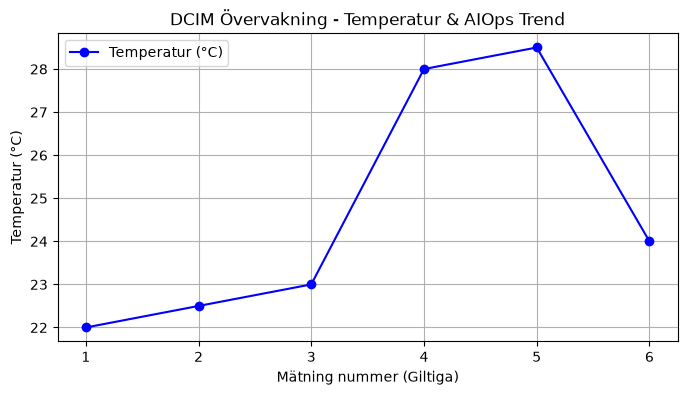

In [48]:
import matplotlib.pyplot as plt


# 1. KLASSER OCH SENSOR (Från Övning 3)
class Server:

    def __init__(self, name: str):
        self.name = name
        self.status = "OK"


class AIOpsSensor:

    def __init__(self, sensor_id: str, target_server: Server):
        self.sensor_id = sensor_id
        self.target_server = target_server
        self.current_temp = 22.0
        self.temp_history = []

    def update_temperature(self, reading):
        try:
            self.current_temp = float(reading)
        except (ValueError, TypeError):
            self.target_server.status = "SENSOR_FAULT"
            return None  # Returnerar None om värdet var trasigt

        self.temp_history.append(self.current_temp)

        if len(self.temp_history) > 3:
            self.temp_history.pop(0)

        if len(self.temp_history) >= 2:
            temp_rise = self.temp_history[-1] - self.temp_history[-2]
            if temp_rise >= 3.0:
                self.target_server.status = "WARNING"
            else:
                self.target_server.status = "OK"

        return self.current_temp  # Returnerar godkänd temperatur


# 2. KÖR SIMULERING OCH SPARA DATA FÖR GRAFEN
server = Server("Web-Server-01")
sensor = AIOpsSensor("TEMP-01", server)

test_readings = [22.0, 22.5, 23.0, 28.0, "FEL_DATA", 28.5, 24.0]

# Två tomma listor för att spara värdena vi vill rita ut
valid_temps = []
time_steps = []

step = 1
for reading in test_readings:
    temp_result = sensor.update_temperature(reading)

    # Spara bara godkända temperaturer i graf-data (hoppa över None)
    if temp_result is not None:
        valid_temps.append(temp_result)
        time_steps.append(step)
        step += 1


# 3. ÖVNING 4: RITA GRAFEN
plt.figure(figsize=(8, 4))  # Sätt storlek på grafen (Bredd, Höjd)

# Rita linjen: X-axel = time_steps, Y-axel = valid_temps
plt.plot(
    time_steps, valid_temps, marker="o", color="blue", label="Temperatur (°C)"
)

# Rubrik och namn på axlarna
plt.title("DCIM Övervakning - Temperatur & AIOps Trend")
plt.xlabel("Mätning nummer (Giltiga)")
plt.ylabel("Temperatur (°C)")

# Rutnät och teckenförklaring
plt.grid(True)
plt.legend()

# Visa grafen i Notebooken
plt.show()

Kodrad	Vad den gör i enkel språkform
import matplotlib.pyplot as plt	Importerar Pythons standardbibliotek för grafer och döper det kort till plt.
if temp_result is not None:	Filtrerar bort trasiga mätvärden ("FEL_DATA"), så att grafen bara ritar ut riktiga tal.
plt.plot(time_steps, valid_temps)	Kopplar samman tidsstegen på X-axeln med temperaturerna på Y-axeln. marker='o' gör att varje mätpunkt får en tydlig prick.
plt.grid(True)	Lägger till ett rutnät bakom linjen så att det är lättare att läsa av graderna.
plt.show()	Renderar och visar den färdiga bilden på skärmen.

Sammanfattning av vad som byggts:
Övning 1: Byggde ett "Sliding Window" (korttidsminne) med append() och pop(0).

Övning 2: Stoppade in minneslogiken i en klass (AIOpsSensor) och jämförde [-1] med [-2] för trendanalys.

Övning 3: Kopplade ihop sensorn med en Server och skyddade koden med try/except och return.

Övning 4: Samlade ihop alla godkända mätvärden i listor och ritade ut utvecklingen med matplotlib.